# Lecture 13 on Binomial Distributions and Hypothesis Tests

To say a random variable $X$ obeys a binomial distribution is to say $X$ represents
the number of true values among $n$ independent boolean random variables, each equal
to true with probability $p$.  For example, let $X$ denote
the number of heads out of $100$ coin flips.  Each flip has a probability $p=.5$ of
being heads.  $X$ thus obeys a binomial distribution $\text{Binomial(100,0.5)}$
where

$$P[X=k] = \binom{n}{k} p^k (1-p)^{n-k}$$

Binomial distributions appear wherever we have a question that has a boolean outcome: 
"Do you approve of President $X$?" or "Would you vote for measure $Y$?"  The binomial 
random variable in the prior case would be the number of people approving of 
President $X$ out of the number that were asked.  The binomial random variable in the
second case would be the number of people who say they would vote for $Y$ out of the
number asked.

In statistics we call each boolean random experiment a Bernoulli trial.  



## Hypothesis Testing with Binmoial Distributions


$$SE(D) = \sqrt{Var(D)}$$

$$

For values of p near 0.5, we can use a Gaussian approximation.

$$X \sim \text{Binomial}(n, p) \approx \mathcal{N}(\mu, \sigma^2)$$

where:
* $\mu = np$
  
* $\sigma^2 = np(1-p)$
  
* $\sigma = \sqrt{np(1-p)}$

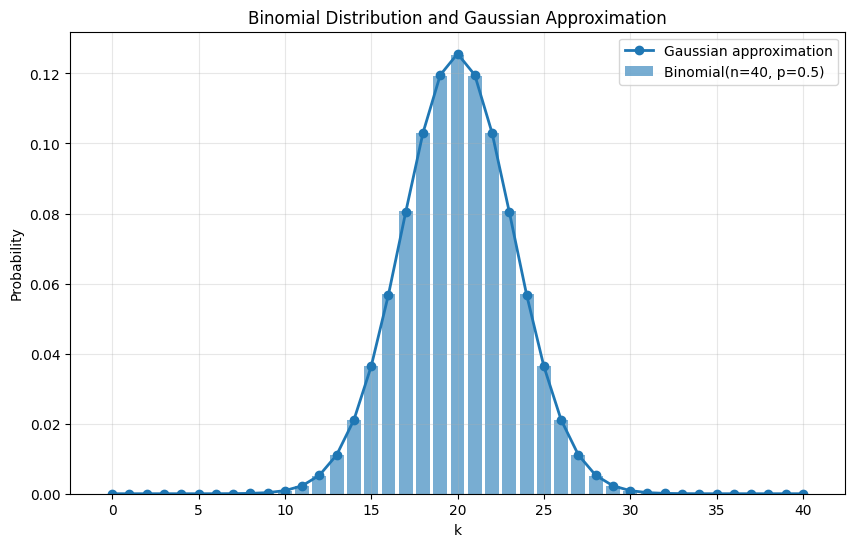

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 40
p = 0.5

# Binomial PMF
x = np.arange(0, n + 1)
binom_pmf = np.array([
    math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))
    for k in x
])

# Gaussian approximation: N(mu, sigma^2)
mu = n * p
sigma = math.sqrt(n * p * (1 - p))

# Use continuity correction for a better overlay:
# Approximate P(X = k) by area from k-0.5 to k+0.5 under the normal curve.
def normal_cdf(z, mean, std):
    return 0.5 * (1 + math.erf((z - mean) / (std * math.sqrt(2))))

gauss_approx = np.array([
    normal_cdf(k + 0.5, mu, sigma) - normal_cdf(k - 0.5, mu, sigma)
    for k in x
])

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x, binom_pmf, width=0.8, alpha=0.6, label=f"Binomial(n={n}, p={p})")
plt.plot(x, gauss_approx, marker="o", linewidth=2, label="Gaussian approximation")

plt.xlabel("k")
plt.ylabel("Probability")
plt.title("Binomial Distribution and Gaussian Approximation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

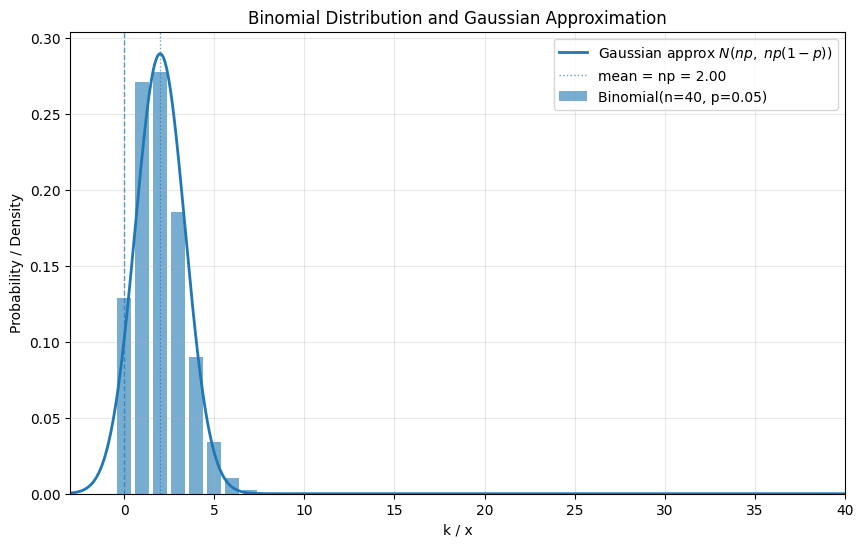

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 40
p = 0.05

# Binomial PMF at integer values
k = np.arange(0, n + 1)
binom_pmf = np.array([
    math.comb(n, i) * (p ** i) * ((1 - p) ** (n - i))
    for i in k
])

# Gaussian approximation to Binomial(n, p)
mu = n * p
sigma = math.sqrt(n * p * (1 - p))

# Smooth x-axis, extended below 0 to show the impossible left tail
x = np.linspace(-3, n + 3, 2000)
gauss_pdf = (1 / (sigma * math.sqrt(2 * math.pi))) * np.exp(
    -0.5 * ((x - mu) / sigma) ** 2
)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(k, binom_pmf, width=0.8, alpha=0.6, label=f"Binomial(n={n}, p={p})")
plt.plot(x, gauss_pdf, linewidth=2, label=r"Gaussian approx $N(np,\;np(1-p))$")

# Helpful reference lines
plt.axvline(0, linestyle="--", linewidth=1, alpha=0.7)
plt.axvline(mu, linestyle=":", linewidth=1, alpha=0.7, label=f"mean = np = {mu:.2f}")

plt.xlim(-3, max(n, mu + 4 * sigma))
plt.xlabel("k / x")
plt.ylabel("Probability / Density")
plt.title("Binomial Distribution and Gaussian Approximation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

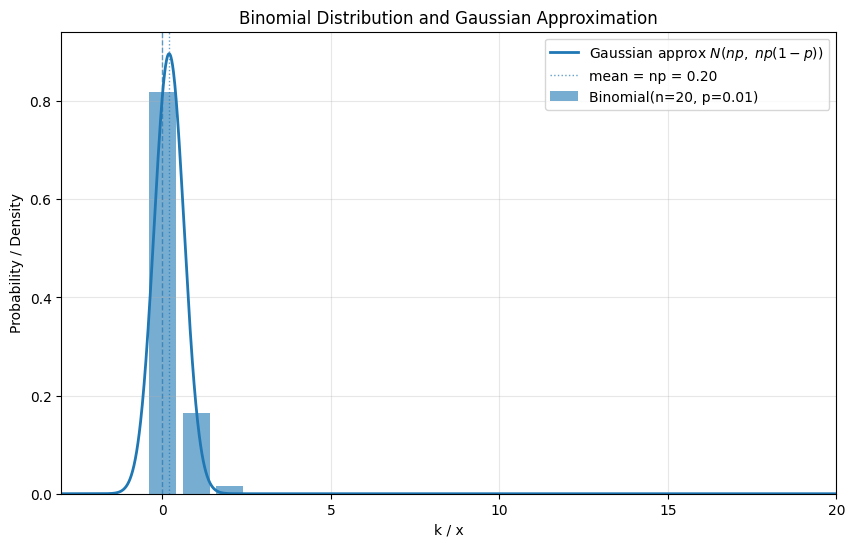

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = q2 0
p = 0.01

# Binomial PMF at integer values
k = np.arange(0, n + 1)
binom_pmf = np.array([
    math.comb(n, i) * (p ** i) * ((1 - p) ** (n - i))
    for i in k
])

# Gaussian approximation to Binomial(n, p)
mu = n * p
sigma = math.sqrt(n * p * (1 - p))

# Smooth x-axis, extended below 0 to show the impossible left tail
x = np.linspace(-3, n + 3, 2000)
gauss_pdf = (1 / (sigma * math.sqrt(2 * math.pi))) * np.exp(
    -0.5 * ((x - mu) / sigma) ** 2
)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(k, binom_pmf, width=0.8, alpha=0.6, label=f"Binomial(n={n}, p={p})")
plt.plot(x, gauss_pdf, linewidth=2, label=r"Gaussian approx $N(np,\;np(1-p))$")

# Helpful reference lines
plt.axvline(0, linestyle="--", linewidth=1, alpha=0.7)
plt.axvline(mu, linestyle=":", linewidth=1, alpha=0.7, label=f"mean = np = {mu:.2f}")

plt.xlim(-3, max(n, mu + 4 * sigma))
plt.xlabel("k / x")
plt.ylabel("Probability / Density")
plt.title("Binomial Distribution and Gaussian Approximation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()